# Data visualization with matplotlib and seaborn

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

## Load data from file
* https://data.who.int/dashboards/covid19/cases?n=c
* https://data.who.int/dashboards/covid19/data

In [10]:
df=pd.read_csv('WHO-COVID-19-global-data.csv')

In [11]:
df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,NaN,0,NaN,0
1,2020-01-12,AF,Afghanistan,EMRO,NaN,0,NaN,0
2,2020-01-19,AF,Afghanistan,EMRO,NaN,0,NaN,0
3,2020-01-26,AF,Afghanistan,EMRO,NaN,0,NaN,0
4,2020-02-02,AF,Afghanistan,EMRO,NaN,0,NaN,0


## Data Description
* Date_reported : Date of reporting to WHO
* Country_code: String ISO Alpha-2 country code
* Country: String Country, territory, area
* WHO_region: String WHO regional offices
* New_cases: Integer New confirmed cases.  Calculated by subtracting previous cumulative case
* Cumulative_cases: Integer Cumulative confirmed cases reported to WHO to date.
* New_deaths: Integer New confirmed deaths. Calculated by subtracting previous cumulative deaths from current cumulative deaths.*
* Cumulative_deaths: Integer Cumulative confirmed deaths reported to WHO to date.

In [12]:
df.describe()

,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,4.729900e+04,6.792000e+04,35070.000000,6.792000e+04
mean,1.644961e+04,2.007182e+06,202.364842,2.141998e+04
std,2.460842e+05,8.420627e+06,1033.409908,8.607108e+04
min,-6.507900e+04,0.000000e+00,-3432.000000,0.000000e+00
25%,1.200000e+01,6.278750e+03,0.000000,3.775000e+01
50%,1.910000e+02,5.732650e+04,6.000000,6.815000e+02
75%,2.461500e+03,6.433805e+05,54.000000,7.694250e+03
max,4.047548e+07,1.034368e+08,47687.000000,1.224428e+06


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67920 entries, 0 to 67919
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date_reported      67920 non-null  object 
 1   Country_code       67637 non-null  object 
 2   Country            67920 non-null  object 
 3   WHO_region         62826 non-null  object 
 4   New_cases          47299 non-null  float64
 5   Cumulative_cases   67920 non-null  int64  
 6   New_deaths         35070 non-null  float64
 7   Cumulative_deaths  67920 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 4.1+ MB


In [14]:
df.shape

(67920, 8)

In [15]:
df.describe(include='all')

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,67920,67637,67920,62826,4.729900e+04,6.792000e+04,35070.000000,6.792000e+04
unique,283,239,240,7,NaN,NaN,NaN,NaN
top,2020-01-05,AF,Afghanistan,EURO,NaN,NaN,NaN,NaN
freq,240,283,283,15565,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.644961e+04,2.007182e+06,202.364842,2.141998e+04
std,NaN,NaN,NaN,NaN,2.460842e+05,8.420627e+06,1033.409908,8.607108e+04
min,NaN,NaN,NaN,NaN,-6.507900e+04,0.000000e+00,-3432.000000,0.000000e+00
25%,NaN,NaN,NaN,NaN,1.200000e+01,6.278750e+03,0.000000,3.775000e+01
50%,NaN,NaN,NaN,NaN,1.910000e+02,5.732650e+04,6.000000,6.815000e+02
75%,NaN,NaN,NaN,NaN,2.461500e+03,6.433805e+05,54.000000,7.694250e+03


## Initial Notes
* The dataset comprises 67920 rows and 8 columns.
* Missing data !!
* Date data (Date_reported) are stored as object data instead of datetime or numerical data and it contains about 1079 unique datas
## Objectives
I'd be moving forward with the following rows and columns and I'd be answering the following question

* What countries have the highest number of new cases and death ?
* What countries have the highest number of cumulative cases and deaths ?
* What WHO_region which also signifies each continent are mostly affected ?
* Using the vaccination information also to answer likely causes of why the countries have the most deaths ?

## Removing Unwanted Columns and Converting the date from object to datetime format

In [16]:
df['Date_reported'] = pd.to_datetime(df['Date_reported'], errors='coerce')

In [17]:
df['year'] = df['Date_reported'].dt.year

In [18]:
df.drop(['Country_code','Date_reported'],axis=1,inplace=True)

In [19]:
df.head(10)

,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,year
0,Afghanistan,EMRO,NaN,0,NaN,0,2020
1,Afghanistan,EMRO,NaN,0,NaN,0,2020
2,Afghanistan,EMRO,NaN,0,NaN,0,2020
3,Afghanistan,EMRO,NaN,0,NaN,0,2020
4,Afghanistan,EMRO,NaN,0,NaN,0,2020
5,Afghanistan,EMRO,NaN,0,NaN,0,2020
6,Afghanistan,EMRO,NaN,0,NaN,0,2020
7,Afghanistan,EMRO,NaN,0,NaN,0,2020
8,Afghanistan,EMRO,1.0,1,NaN,0,2020
9,Afghanistan,EMRO,NaN,1,NaN,0,2020


In [20]:
df['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia (Plurinational State of)',
       'Bonaire, Saint Eustatius and Saba', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "C�te d'Ivoire",
       'Croatia', 'Cuba', 'Cura�ao', 'Cyprus', 'Czechia',
       "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecua

## Countries with most cumulative covid 19 cases

In [21]:
covid_Cumulative_cases = pd.DataFrame(df.groupby("Country")['Cumulative_cases']
                               .agg('sum')).sort_values(by='Cumulative_cases',ascending=False,axis=0)

covid_Cumulative_cases.head()

,Cumulative_cases
Country,
United States of America,19667084280
China,12899940405
India,9415441092
Brazil,7402239110
France,6751311840


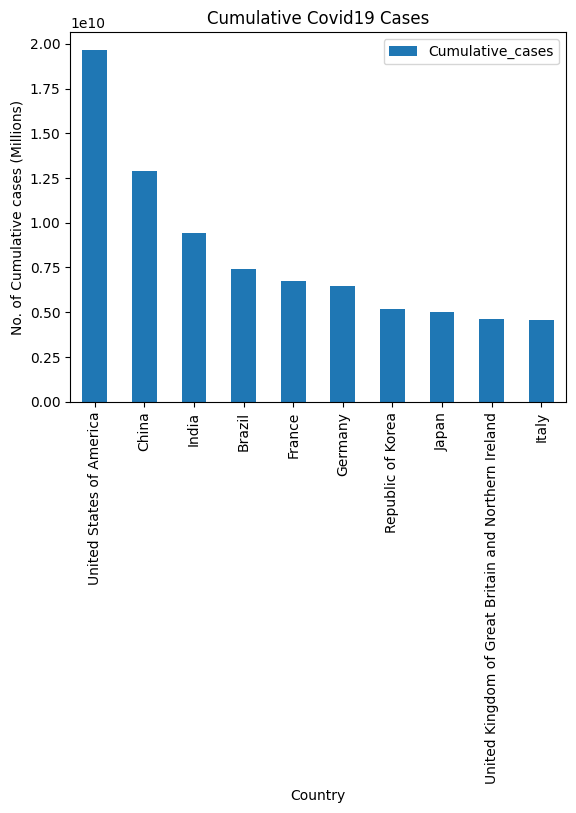

In [27]:
covid_Cumulative_cases.head(10).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of Cumulative cases (Millions)',title = 'Cumulative Covid19 Cases')
plt.show()

## Countries with the least covid19 cases

In [28]:
covid_Cumulative_least_cases = pd.DataFrame(df.groupby("Country")['Cumulative_cases']
                               .agg('sum')).sort_values(by='Cumulative_cases',ascending=True,axis=0)

In [29]:
covid_Cumulative_least_cases.head(20)

,Cumulative_cases
Country,
Turkmenistan,0
Democratic People's Republic of Korea,0
International conveyance (Kiribati),422
Pitcairn,600
International conveyance (American Samoa),934
International conveyance (Solomon Islands),1059
International conveyance (Vanuatu),2568
Holy See,6618
International commercial vessel,7627


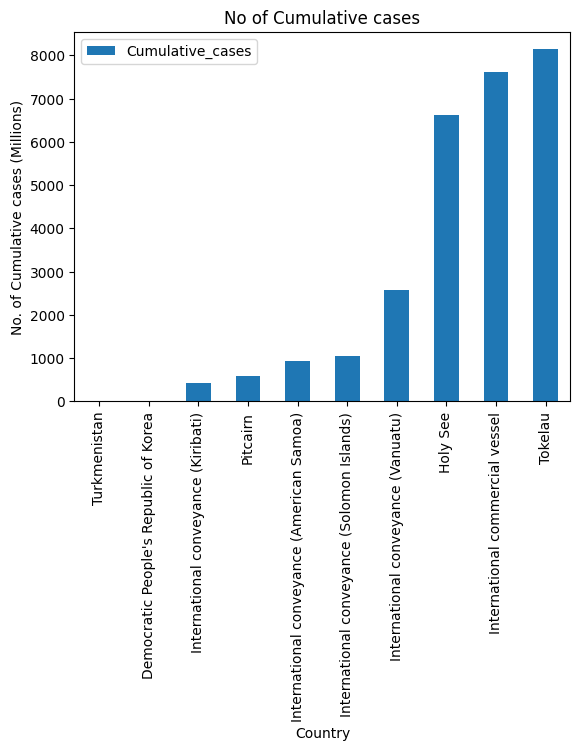

In [30]:
covid_Cumulative_least_cases.head(10).plot(kind='bar', xlabel = 'Country', ylabel = 'No. of Cumulative cases (Millions)',title = 'No of Cumulative cases')
plt.show()

## Top  countries New cases

In [34]:
covid_new_cases = pd.DataFrame(df.groupby("Country")['New_cases']
                               .agg('sum')).sort_values(by='New_cases',ascending=False,axis=0)

covid_new_cases.head()

,New_cases
Country,
United States of America,103436829.0
China,99381761.0
India,45050188.0
France,39039783.0
Germany,38437864.0


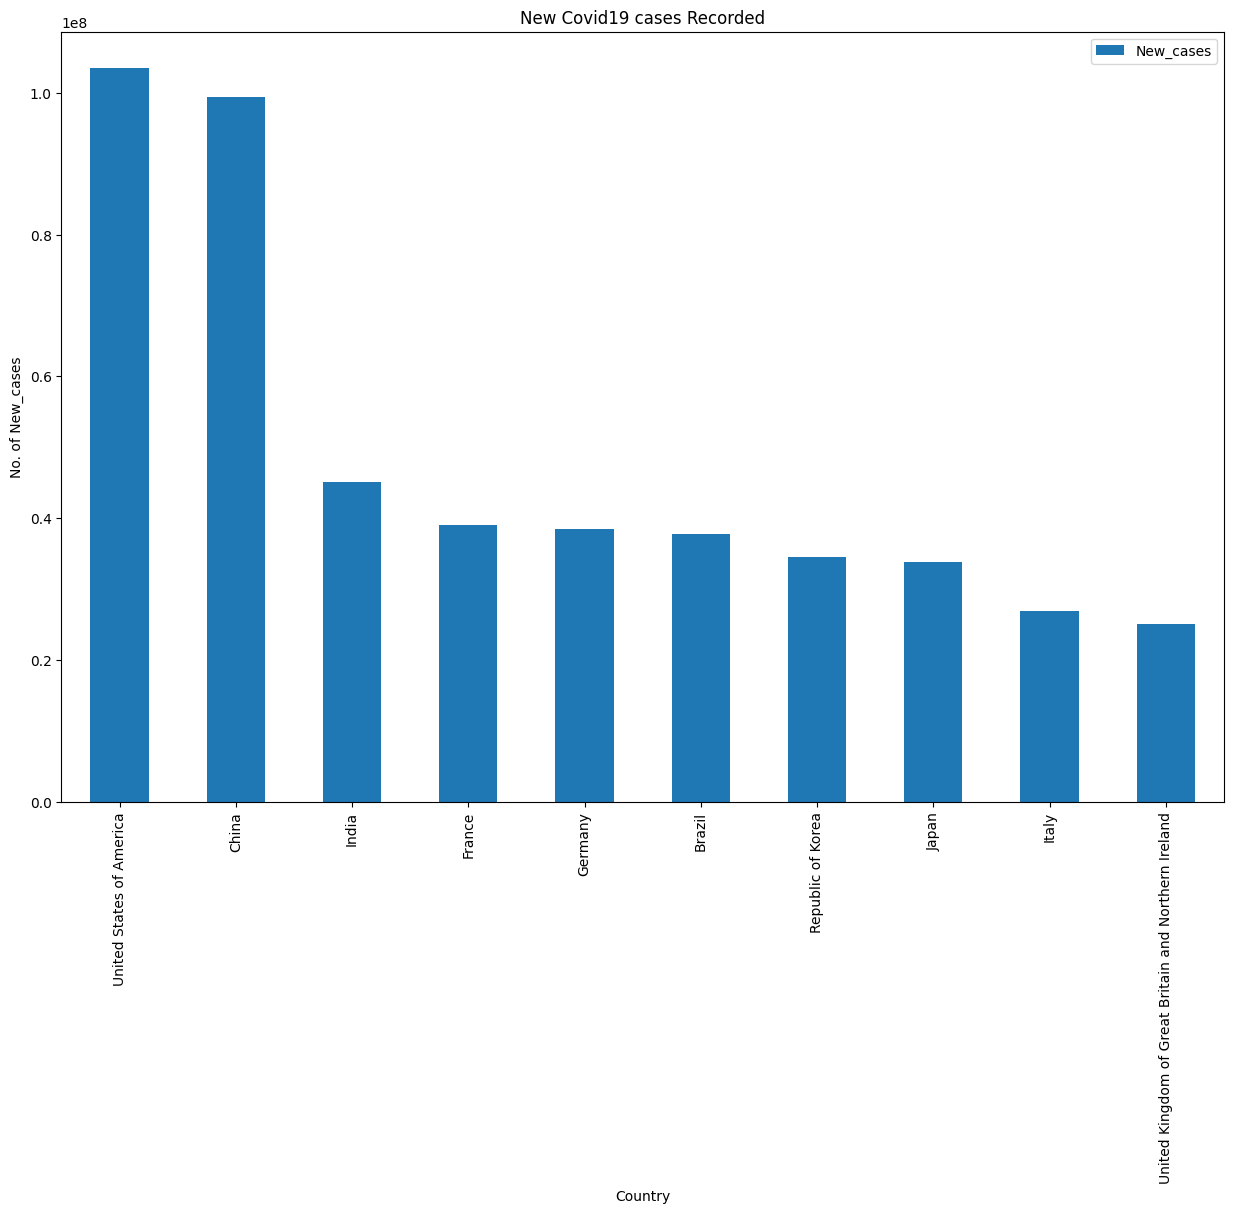

In [35]:
covid_new_cases.head(10).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of New_cases',title = 'New Covid19 cases Recorded', figsize=(15,10))
plt.show()

## Least countries new case

In [36]:
covid_least_new_cases = pd.DataFrame(df.groupby("Country")['New_cases']
                               .agg('sum')).sort_values(by='New_cases',ascending=True,axis=0)

covid_least_new_cases.head(10)

,New_cases
Country,
Turkmenistan,0.0
Democratic People's Republic of Korea,0.0
International conveyance (Kiribati),2.0
International conveyance (American Samoa),4.0
Pitcairn,4.0
International conveyance (Solomon Islands),5.0
International conveyance (Vanuatu),12.0
Holy See,26.0
International commercial vessel,29.0


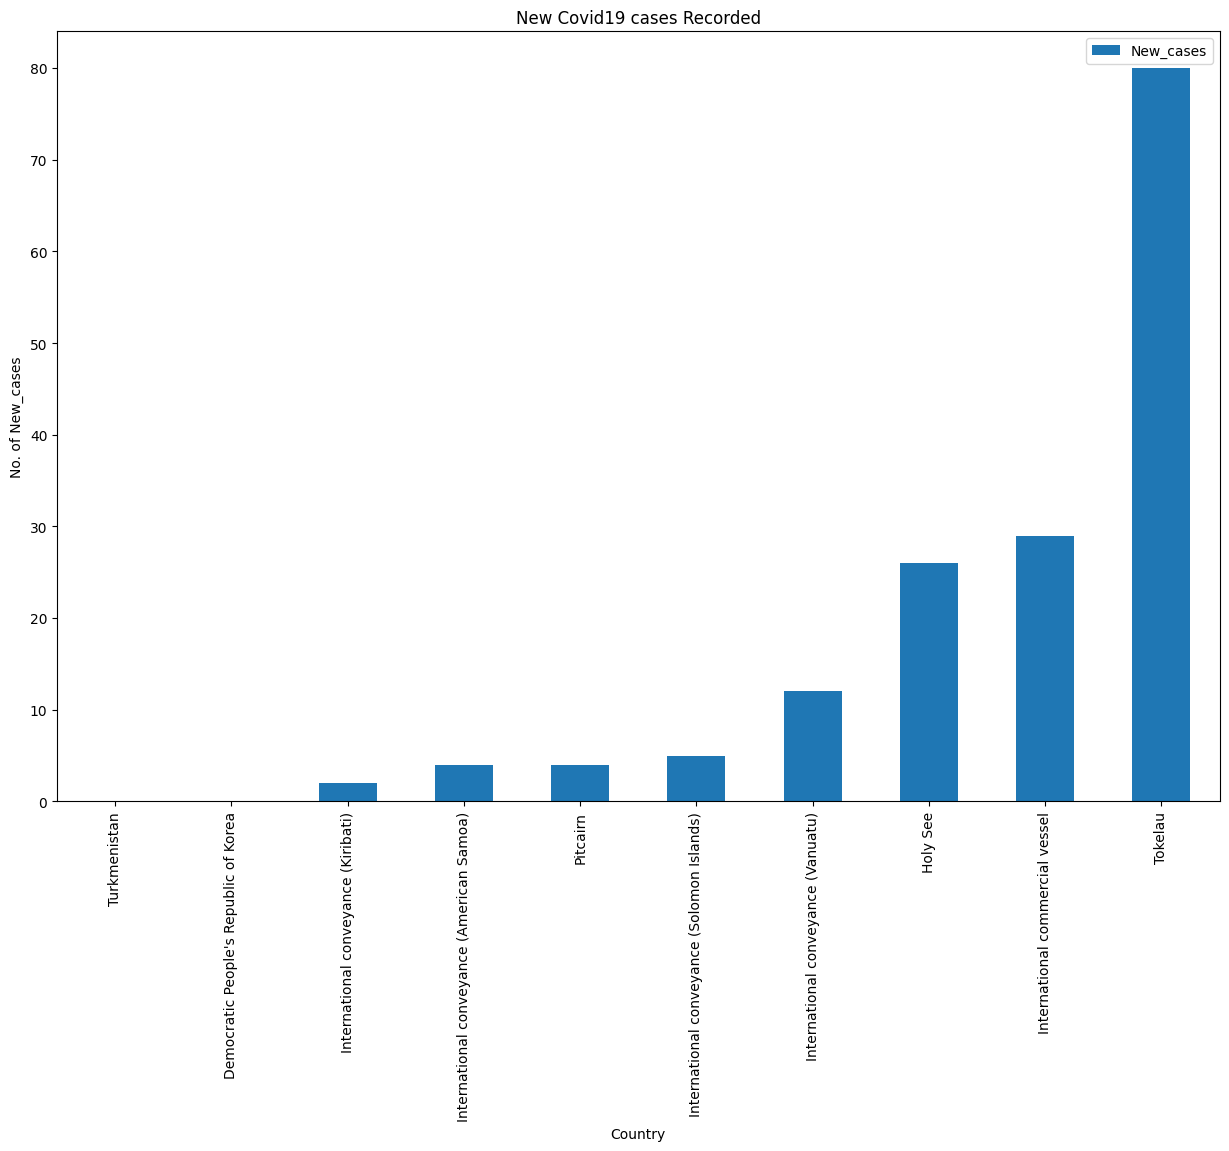

In [37]:
covid_least_new_cases.head(10).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of New_cases',title = 'New Covid19 cases Recorded', figsize=(15,10))
plt.show()

## Top death

In [38]:
covid_new_death = pd.DataFrame(df.groupby("Country")['New_deaths']
                               .agg('sum')).sort_values(by='New_deaths',ascending=False,axis=0)

covid_new_death.head()

,New_deaths
Country,
United States of America,1224428.0
Brazil,702875.0
India,533693.0
Russian Federation,404290.0
Mexico,334818.0


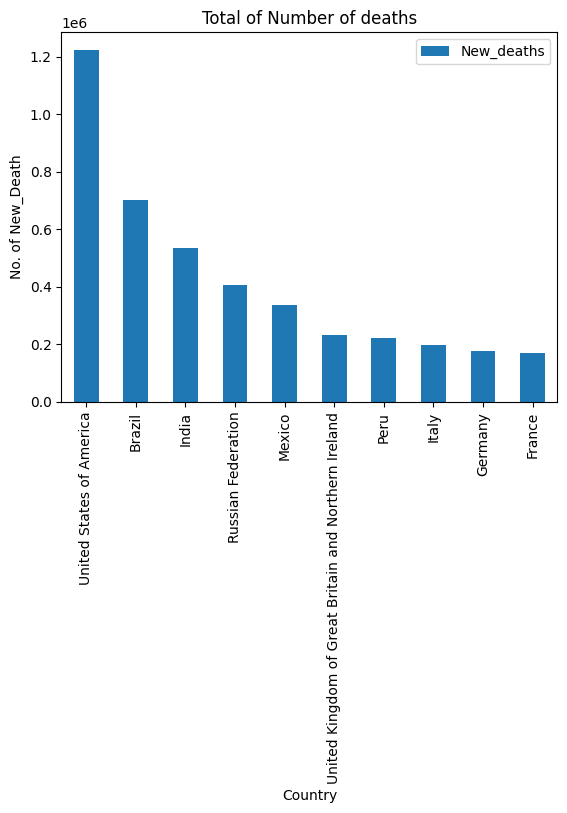

In [39]:
covid_new_death.head(10).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of New_Death',title = 'Total of Number of deaths')
plt.show()

In [40]:
covid_new_least_death = pd.DataFrame(df.groupby("Country")['New_deaths']
                               .agg('sum')).sort_values(by='New_deaths',ascending=True,axis=0)

covid_new_least_death.head(10)

,New_deaths
Country,
International conveyance (Solomon Islands),0.0
International conveyance (Vanuatu),0.0
International conveyance (American Samoa),0.0
International commercial vessel,0.0
Tokelau,0.0
Democratic People's Republic of Korea,0.0
Saint Helena,0.0
Turkmenistan,0.0
Pitcairn,0.0


## Least countries death

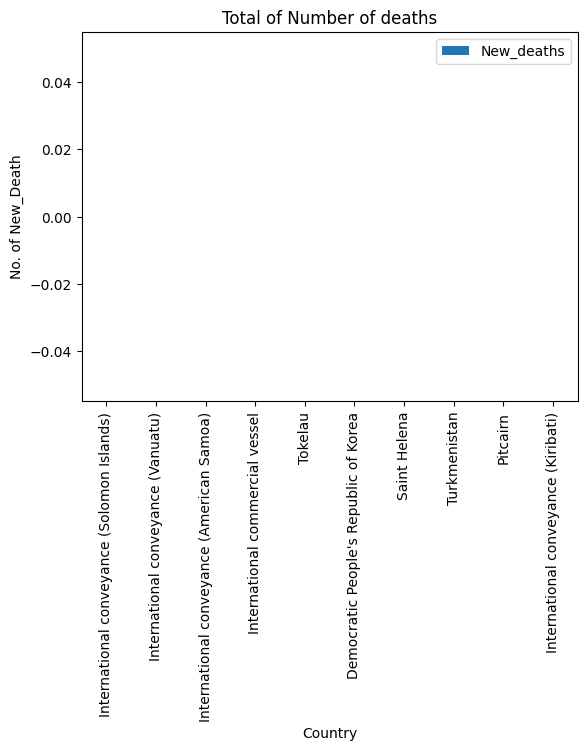

In [43]:
covid_new_least_death.head(10).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of New_Death',title = 'Total of Number of deaths')
plt.show()

## Top acumulative death

In [44]:
covid_Cumulative_deaths = pd.DataFrame(df.groupby("Country")['Cumulative_deaths']
                               .agg('sum')).sort_values(by='Cumulative_deaths',ascending=False,axis=0)

covid_Cumulative_deaths.head()

,Cumulative_deaths
Country,
United States of America,239214834
Brazil,151595542
India,114355484
Russian Federation,79156831
Mexico,74865477


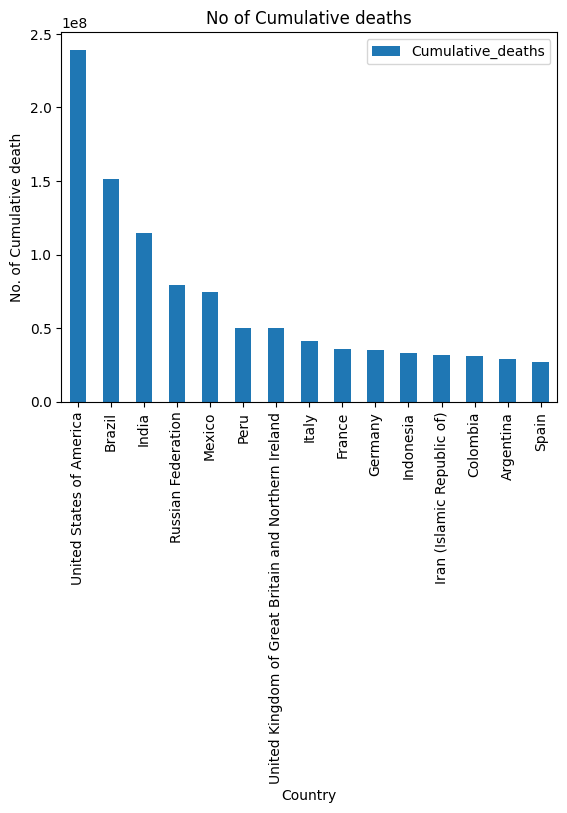

In [45]:
covid_Cumulative_deaths.head(15).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of Cumulative death',title = 'No of Cumulative deaths')
plt.show()

## Least acumulative death

In [46]:
covid_Cumulative_least_deaths = pd.DataFrame(df.groupby("Country")['Cumulative_deaths']
                               .agg('sum')).sort_values(by='Cumulative_deaths',ascending=True,axis=0)

covid_Cumulative_least_deaths.head(10)

,Cumulative_deaths
Country,
Tokelau,0
International conveyance (Vanuatu),0
Holy See,0
International conveyance (Solomon Islands),0
Democratic People's Republic of Korea,0
International conveyance (Kiribati),0
Pitcairn,0
Turkmenistan,0
International conveyance (American Samoa),0


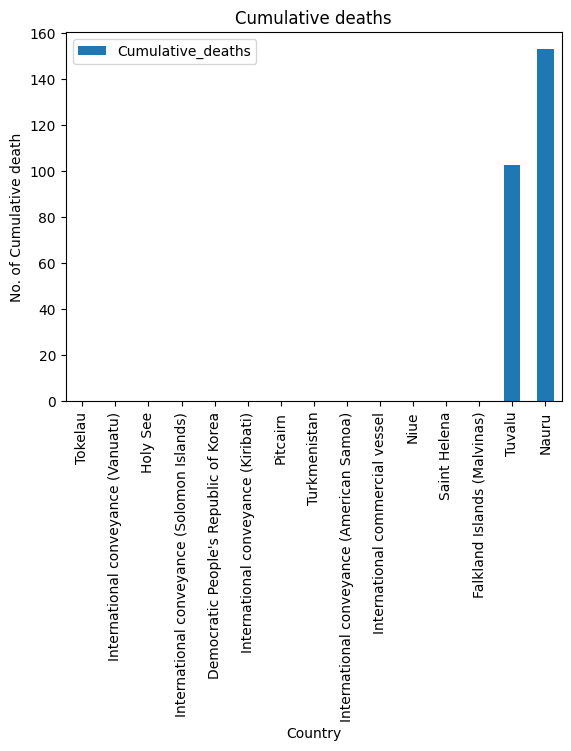

In [47]:
covid_Cumulative_least_deaths.head(15).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of Cumulative death',title = 'Cumulative deaths')
plt.show()

## In Southeast Asia

SEARO can refer to two distinct but related entities: the WHO South-East Asia Region and the Sexual Exploitation and Abuse Risk Overview (SEARO) composite index.

In [48]:
Covid_19 = df

In [58]:
searo_death_cases= Covid_19[Covid_19['WHO_region'] =='SEARO']
#  top ten most affected countries

top_countries = pd.DataFrame(searo_death_cases.groupby("Country")['Cumulative_cases']
                               .agg('sum')).sort_values(by='Cumulative_cases',ascending=False,axis=0)


top_countries.head(10)

,Cumulative_cases
Country,
India,9415441092
Indonesia,1324385012
Thailand,858635163
Bangladesh,426311223
Nepal,210592000
Sri Lanka,134945810
Myanmar,128476044
Maldives,36035460
Bhutan,10518178


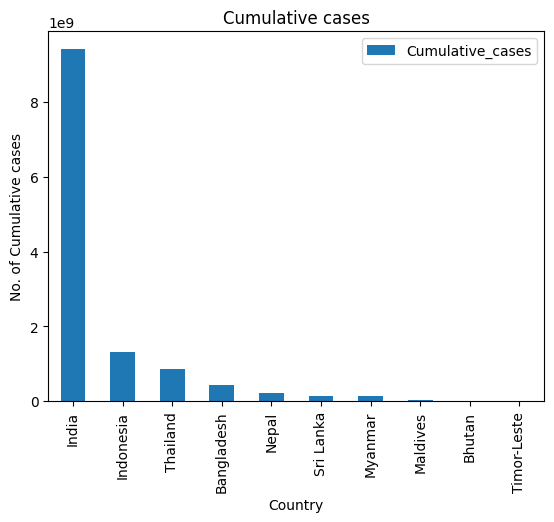

In [59]:
top_countries.head(10).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of Cumulative cases',title = 'Cumulative cases')
plt.show()

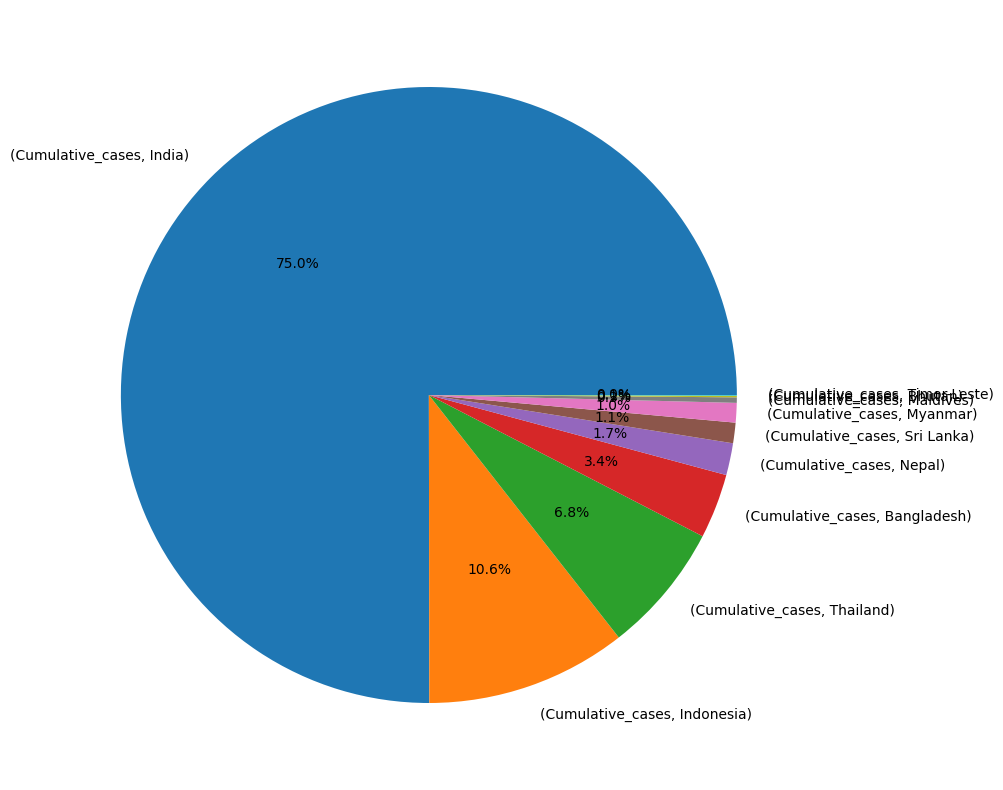

In [60]:
top_countries.head(10).unstack(level=0).plot(
    kind='pie',
    stacked=True,
    subplots=True,
    autopct='%1.1f%%',
    figsize=(10, 10),
    legend=False,
    )
plt.show()

## Cumulative Death Cases

In [61]:
# Top ten cases in Southeast Asia
searo_death_cases=Covid_19[Covid_19['WHO_region']=='SEARO']
searo_death_cases=pd.DataFrame(searo_death_cases.groupby("Country")['Cumulative_deaths']
                               .agg('sum')).sort_values(by='Cumulative_deaths',ascending=False,axis=0)
searo_death_cases.head(10)

,Cumulative_deaths
Country,
India,114355484
Indonesia,33255408
Bangladesh,6316429
Thailand,6274716
Myanmar,3983360
Sri Lanka,3296674
Nepal,2567070
Maldives,64974
Timor-Leste,26798


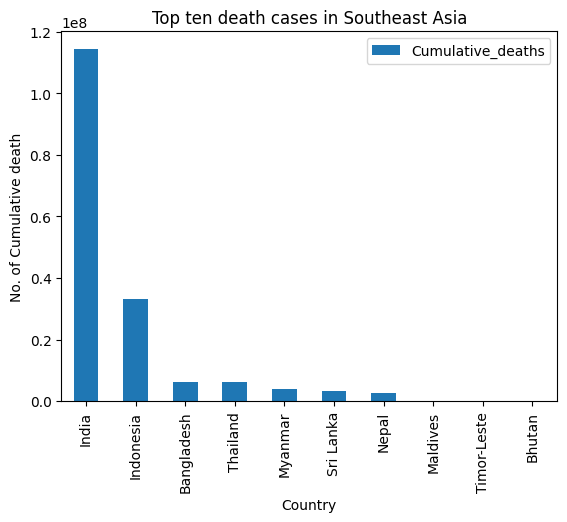

In [63]:
searo_death_cases.head(10).plot(kind='bar',  xlabel = 'Country', ylabel = 'No. of Cumulative death',title = 'Top ten death cases in Southeast Asia')
plt.show()

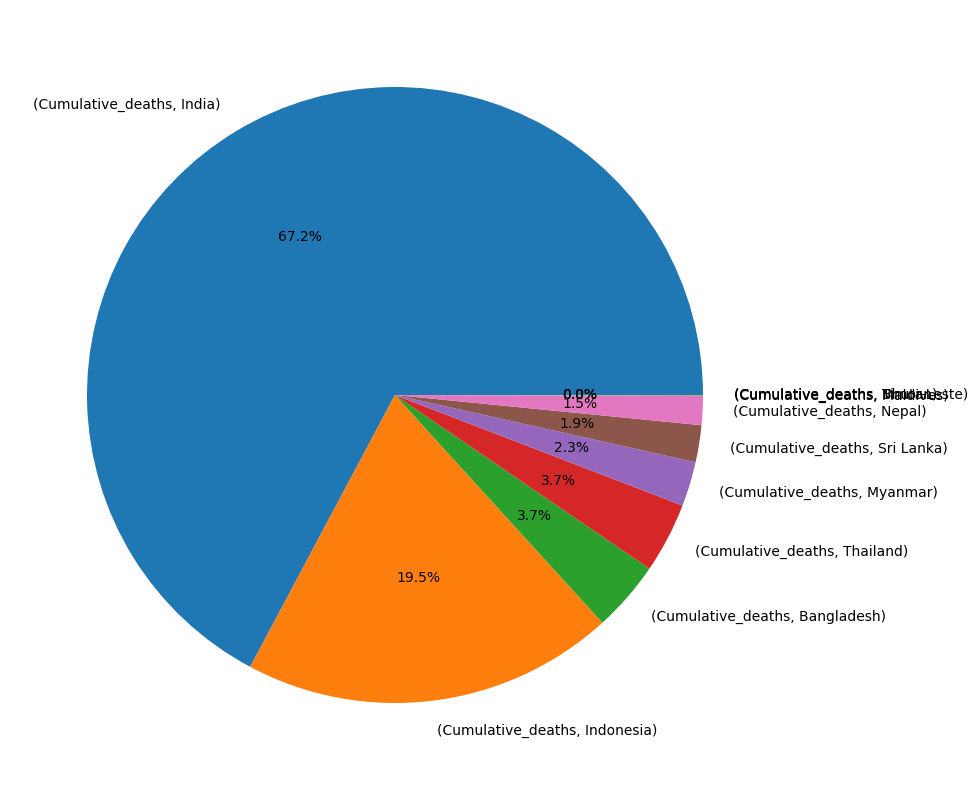

In [64]:
searo_death_cases.head(10).unstack(level=0).plot(
    kind='pie',
    stacked=True,
    subplots=True,
    autopct='%1.1f%%',
    figsize=(10, 10),
    legend=False,
    )
plt.show()

In [66]:
searo_death_cases=Covid_19[Covid_19['WHO_region']=='SEARO']
# sum of total death cases in Southeast Asia

print('Southeast Asia has a total cumulative death of about', searo_death_cases['Cumulative_deaths'].sum()) 

Southeast Asia has a total cumulative death of about 170144543
